# TASK 1

abTEM version: 1.0.0beta34


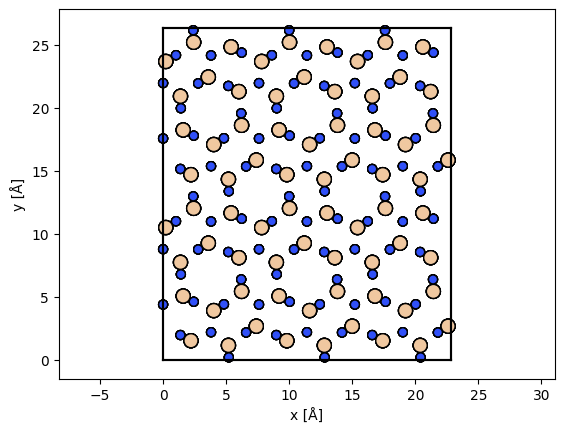

Tiled cell dimensions [Å]: [22.8135     26.34276073 49.3884    ]
Specimen thickness along z [Å]: 49.3884
Specimen thickness along z [nm]: 4.93884


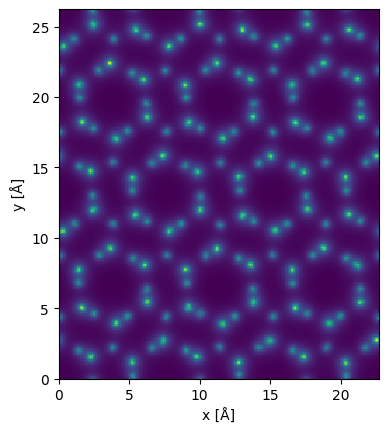

In [ ]:
!pip install -q abtem==1.0.0b34 ase matplotlib numpy==1.26.4

%matplotlib inline

import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt

print(f"abTEM version: {abtem.__version__}")

# Build the Si3N4 structure
structure = ase.Atoms(
    'Si6N8',
    positions=[
        (4.015308131006949, 3.9110253242355126, 2.1788993100000003),
        (2.422878997737693, -1.15285715796029, 0.72629977),
        (5.3947013511357, -1.5218461833564767, 0.72629977),
        (2.2098430845971873, 1.521846183356477, 2.1788993100000003),
        (5.181665437995193, 1.1528571579602902, 2.1788993100000003),
        (3.5892363047259375, -3.9110253242355126, 0.72629977),
        (3.802272178664434, 2.195242888517426, 2.1788993100000003),
        (3.80227217866444, -2.1952428885174267, 0.72629977),
        (6.2321062558996125, -1.9713791971906662, 2.1788993100000003),
        (4.8233175932090955, 4.411472738097657, 0.72629977),
        (5.21106080556961, 0.2027673026395847, 0.72629977),
        (2.393483551759255, -0.20287673026395803, 2.1788993100000003),
        (1.3724381798332734, 1.9713791971906653, 0.72629977),
        (2.781226842523792, -4.411472738097657, 2.1788993100000003),
    ],
    cell=[7.6045, 7.6045, 2.9052, 90, 90, 120]
)

# Orthogonalize the unit cell
structure_orthogonal = abtem.structures.orthogonalize_cell(structure)

# Visualize the orthogonalized structure
abtem.show_atoms(structure_orthogonal * (3, 2, 6), plane='xy')
plt.show()

# Tile the structure to get ~5 nm thickness
atoms_tiled = structure_orthogonal * (3, 2, 17)

# Create frozen phonon configurations
frozen_phonons = abtem.FrozenPhonons(
    atoms_tiled,
    num_configs=8,
    sigmas={'Si': 0.1, 'N': 0.1},
)

# Create the potential
potential = abtem.Potential(
    frozen_phonons,
    sampling=0.1,
    slice_thickness=2.0,
    parametrization='kirkland',
)

# Check the specimen size
print("Tiled cell dimensions [Å]:", atoms_tiled.cell.lengths())
print("Specimen thickness along z [Å]:", atoms_tiled.cell.lengths()[2])
print("Specimen thickness along z [nm]:", atoms_tiled.cell.lengths()[2] / 10)

# Plot the projected potential
potential.project().show(cmap='viridis')
plt.show()

# TASK 2

TDS:   0%|          | 0/8 [00:00<?, ?it/s]

Multislice:   0%|          | 0/25 [00:00<?, ?it/s]

Potential:   0%|          | 0/25 [00:00<?, ?it/s]

(<Axes: xlabel='x [Å]', ylabel='y [Å]'>,
 <matplotlib.image.AxesImage at 0x7f4966ee5310>)

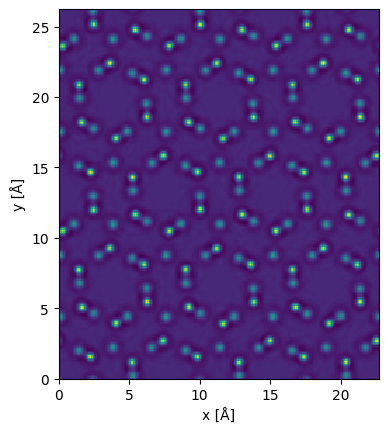

In [ ]:
wave = abtem.PlaneWave(energy=300e3)

# multislice propagation
exit_waves = wave.multislice(potential)

# mean exit-wave intensity
exit_waves.intensity().mean(0).show(cmap='viridis')

# TASK 3

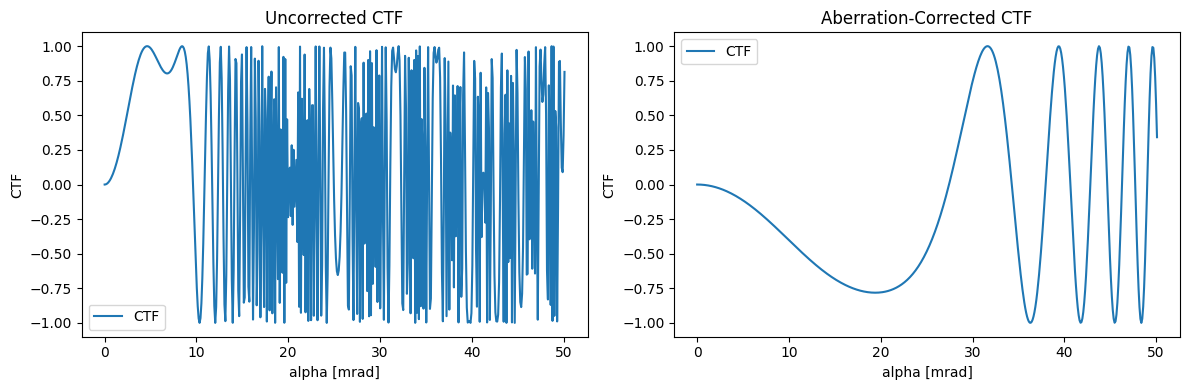

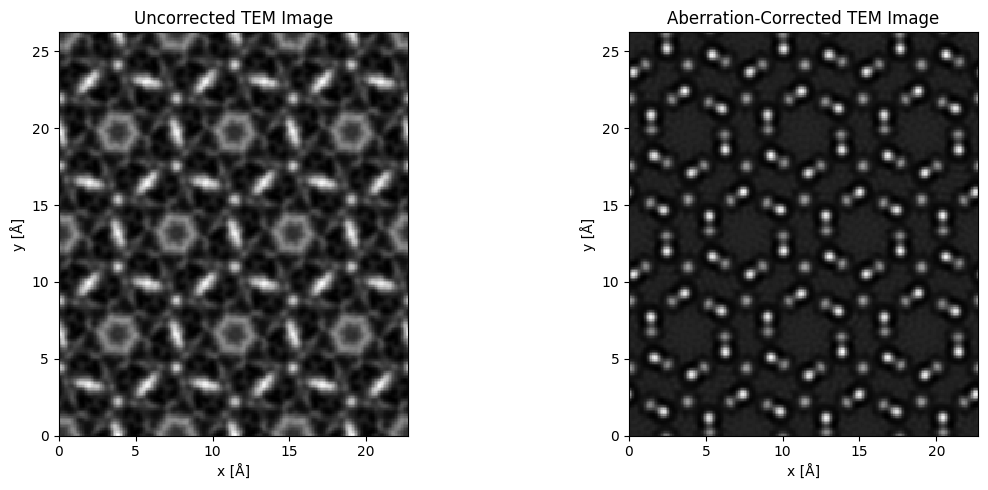

In [ ]:
# Define the uncorrected CTF
parameters_uncorrected = {
    'C10': -600,
    'C30': 1.3e7,
}
ctf_uncorrected = abtem.CTF(energy=300e3, parameters=parameters_uncorrected)

# Define the aberration-corrected CTF
parameters_corrected = {
    'C10': 30,
    'C30': -8e4,
}
ctf_corrected = abtem.CTF(energy=300e3, parameters=parameters_corrected)

# Plot both CTFs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ctf_uncorrected.show(ax=axes[0])
axes[0].set_title('Uncorrected CTF')

ctf_corrected.show(ax=axes[1])
axes[1].set_title('Aberration-Corrected CTF')

plt.tight_layout()
plt.show()

# Apply each CTF to the exit waves
image_uncorrected = exit_waves.apply_ctf(ctf_uncorrected)
image_corrected = exit_waves.apply_ctf(ctf_corrected)

# Plot the mean image intensities side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

image_uncorrected.intensity().mean(0).show(cmap='gray', ax=axes[0])
axes[0].set_title('Uncorrected TEM Image')

image_corrected.intensity().mean(0).show(cmap='gray', ax=axes[1])
axes[1].set_title('Aberration-Corrected TEM Image')

plt.tight_layout()
plt.show()

# TASK 4

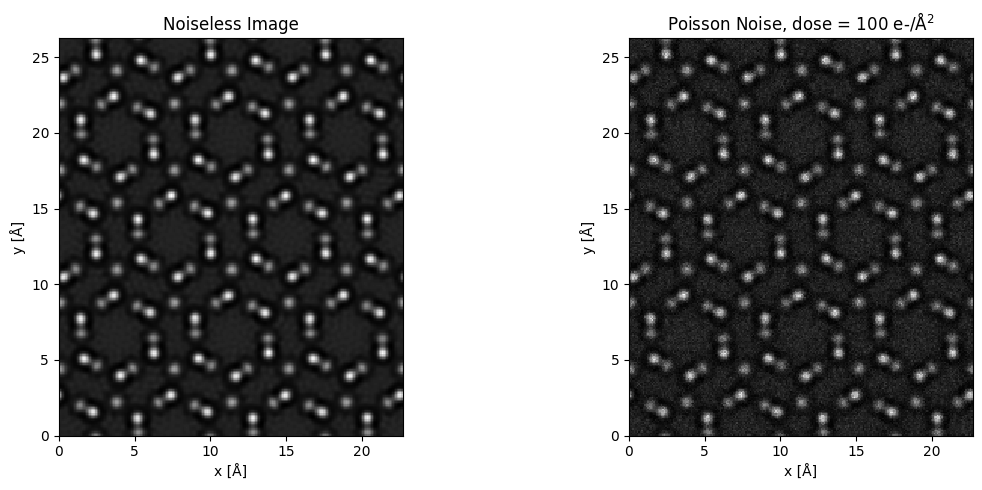

In [ ]:
dose = 100  # e-/Å^2

# Get the mean aberration-corrected image
noiseless_image = image_corrected.intensity().mean(0)

# Convert to array and normalize to [0, 1]
image_array = noiseless_image.array
image_norm = image_array / image_array.max()

# Apply Poisson noise
counts = np.random.poisson(image_norm * dose)
noisy_array = counts / dose

# Copy the noiseless image object and replace the data
noisy_image = noiseless_image.copy()
noisy_image.array[:] = noisy_array

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

noiseless_image.show(cmap='gray', ax=axes[0])
axes[0].set_title('Noiseless Image')

noisy_image.show(cmap='gray', ax=axes[1])
axes[1].set_title(f'Poisson Noise, dose = {dose} e-/Å$^2$')

plt.tight_layout()
plt.show()

# TASK 5

After adding Poisson noise with a dose of 100 e⁻/Å²，background fluctuations increase significantly and the signal-to-noise ratio decreases.Compared with the noiseless image,the noisy image appears grainier,and the atomic columns become less sharp and more difficult to distinguish,even though the overall lattice pattern remains visible.

**1.Contrast Transfer Function (CTF):**

The uncorrected CTF oscillates much more rapidly with spatial frequency,shows stronger envelope decay,and has more frequent zero crossings.This means that the transferred contrast changes sign more often,high-resolution information is interrupted more frequently,and phase reversals are more severe.In contrast, the aberration-corrected CTF is smoother,has fewer zero crossings,and preserves useful contrast over a broader spatial-frequency range.As a result,high-frequency information related to atomic-scale details is transferred more consistently.This is why the aberration-corrected TEM image shows sharper, more localized atomic columns,and the uncorrected image appears more delocalized and visually complicated.

**2.Defocus and Contrast:**

In a traditional uncorrected TEM,imaging at exactly zero defocus is usually avoided because the phase contrast is very weak over much of the spatial-frequency range,so atomic columns and fine structural features are not clearly visible.The strong spherical aberration also limits the direct interpretability of the image at zero defocus.The Scherzer defocus is important because it provides a special underfocus condition that balances defocus and spherical aberration,maximizing the range of spatial frequencies transferred with useful contrast.Therefore, it gives stronger and more interpretable lattice and atomic-column contrast in conventional TEM.

**3.Simulation vs. Reality:**

Adding Poisson noise increases background fluctuations and lowers the signal-to-noise ratio,making the image grainier and reducing the clarity of atomic columns.In our simulation, the overall lattice pattern remains visible, but the atomic columns become less sharp and fine details are harder to distinguish.In a real HRTEM experiment, image quality can be further degraded by many additional factors,such as chromatic aberration,sample drift,specimen vibration,beam damage,contamination, residual lens aberrations,imperfect alignment,detector noise and local thickness variations.These effects can further reduce image contrast and make structural interpretation more difficult.

**4.Multislice Algorithm:**

For a specimen about 5 nm thick,the kinematic approximation based on a single projected potential is not sufficient because it assumes only weak single scattering.In reality, the electron wave is modified continuously as it propagates through the crystal,and multiple elastic scattering events accumulate through the sample thickness.The multislice method is necessary because it divides the specimen into thin slices and updates the electron wave after each propagation step.This makes it much more accurate for modeling phase evolution, dynamical scattering,and the final exit wave in a thicker sample, leading to more realistic HRTEM image simulations.